# Cracking Wireless Equivalent Privacy (WEP) Pre-Shared Keys (PSKs) with the Fluhrer, Mantin, Shamir (FMS) Attack

Based on [Weaknesses in the Key-Scheduling Algorithm of RC4](https://www.cs.cornell.edu/people/egs/615/rc4_ksaproc.pdf) and [FMS-Attack](https://github.com/jackieden26/FMS-Attack).

Due to the weaknesses of the RC4 cipher it is possible to statistically determine the bytes of a WEP PSK if you have the initialization vectors (which are transmitted in plain text) and the first byte of what is being encrypted.
Most WiFi frames are Subnet Access Protocol frames so we know the first byte will usually be 0xAA.

Let's start by defining our own secret key.
I've used three bytes, but it should be possible to use more.

In [24]:
import matplotlib.pyplot as plt
import random
import ipywidgets as widgets
from IPython.display import display

key = [10, 100, 200]

print(f"PSK being used: {key}")

PSK being used: [10, 100, 200]


## RC4

The RC4 cipher is a simple-to-implement stream cipher invented by Ronald Rivest in 1987.
It was proprietary but was later leaked in 1994.
This is why you will sometimes see it referred to as ARC4: Alleged RC4.

RC4 has two major parts, the Key-Scheduling Algorithm (KSA) and the Pseudo-Random Generation Algorithm (PRGA).
RC4 maintains a state array, _S_, of 256 indexes that change as the KSA and PRGA are used.

## RC4 KSA

The KSA sets up the state array, _S_, based on a private key.
It starts by initializing _S_ so that each index is a number from 0 to 255, counting up.
It then swaps indexes in _S_ according to key values.
You can see it's implementation below:


In [25]:
def ksa(key):
    S = list(range(256))
    j = 0
    for i in range(256):
        j = (j + S[i] + key[i % len(key)]) % 256
        S[i], S[j] = S[j], S[i]
    return S

## RC4 Pseudo-Random Generation Algorithm (PRGA)

The PRGA gives "random" numbers based on _S_ while changing _S_ on every iteration.
This implementation takes _S_ and two iterators _i_ and _j_.
It returns an updated _S_, _i_, _j_ and the resulting "random" number.
These "random" numbers are known as the _keystream_.

In [26]:
def prga(S, i, j):
    i = (i + 1) % 256
    j = (j + S[i]) % 256
    S[i], S[j] = S[j], S[i]
    keystream_byte = S[(S[i] + S[j]) % 256]
    return (S, i, j, keystream_byte)

## WEP

WEP uses an initialization vector combined with a PSK to set up the state array _S_ for RC4.
It then uses the keystream from RC4 to generate values to XOR with the data as a means of encryption.

## Weak Initialization Vectors (IVs)

It turns out that certain IVs generated by WEP can be used to make guesses as to what the PSK is.
If an IV is of the form _[A + 3, 255, N]_ where A is the index of the PSK byte we're looking for and N is any number between 0 and 255 it is considered a weak.
Here we generate a lot (2000 by default) of weak IVs as well as the first encoded byte using the RC4 cipher.
Note that just because an IV is weak it _does not_ necessarily mean we can use it to decode the PSK, that also depends on whether or not it meets the _resolved condition_.
Take a look at the weak IVs we generate here and see if you notice a pattern in how they are formed.

In [27]:
data = []
for _ in range(2000):
    iv = [
        random.randint(0, len(key) - 1) + 3,
        255,
        random.randint(0, 255)
    ]
    rc4_key = iv + key

    S = ksa(rc4_key)
    S, i, j, keystream_byte = prga(S, 0, 0)

    cipher_byte = 0xAA ^ keystream_byte # First byte in our SNAP header is 0xAA
    data.append((iv[0], iv[1], iv[2], cipher_byte))
    
print(data)

[(4, 255, 251, 115), (4, 255, 138, 77), (5, 255, 171, 219), (3, 255, 239, 172), (4, 255, 155, 141), (5, 255, 166, 44), (3, 255, 122, 164), (4, 255, 250, 127), (4, 255, 190, 26), (3, 255, 52, 85), (5, 255, 187, 131), (4, 255, 253, 160), (4, 255, 114, 139), (5, 255, 70, 23), (3, 255, 142, 149), (4, 255, 23, 7), (5, 255, 43, 24), (4, 255, 127, 144), (4, 255, 255, 133), (3, 255, 243, 169), (5, 255, 208, 136), (3, 255, 104, 210), (3, 255, 91, 201), (4, 255, 180, 245), (5, 255, 204, 251), (3, 255, 247, 63), (5, 255, 113, 63), (4, 255, 234, 153), (3, 255, 33, 74), (4, 255, 73, 12), (5, 255, 15, 40), (4, 255, 206, 160), (5, 255, 48, 188), (4, 255, 76, 249), (3, 255, 123, 227), (5, 255, 150, 249), (5, 255, 68, 15), (4, 255, 228, 171), (4, 255, 60, 178), (3, 255, 42, 30), (4, 255, 123, 89), (4, 255, 225, 90), (3, 255, 26, 114), (4, 255, 84, 52), (5, 255, 146, 250), (3, 255, 14, 109), (4, 255, 121, 174), (4, 255, 154, 16), (4, 255, 142, 249), (3, 255, 121, 119), (3, 255, 210, 43), (5, 255, 196, 1

## Guessing the PSK

If you have enough weak IVs with the first cipher byte, which in the wild can be acquired by sniffing WiFi traffic, you can simulate the KSA initialization process, check to see if the resolved condition is met, and then use that to make a guess as to what that PSK byte is.
With enough guesses you'll find that statistically one value is more probable than all the others.

Here we generate and plot the frequency of "hits" for each of the 256 possible values that a key byte can be.
Hopefully you can see in the plots that one particular value stands out for each index.

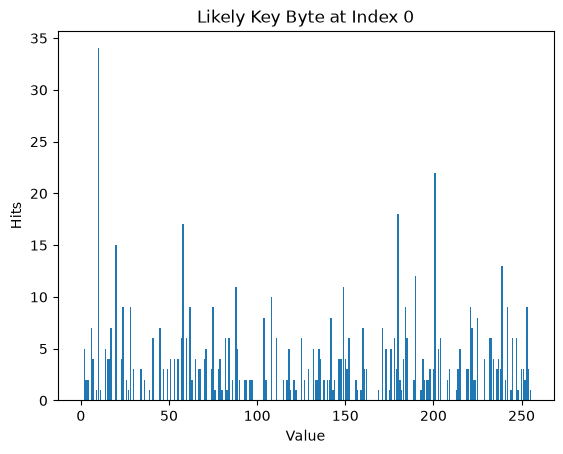

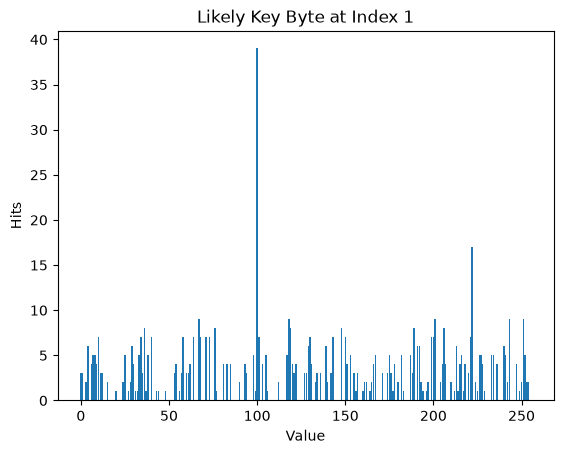

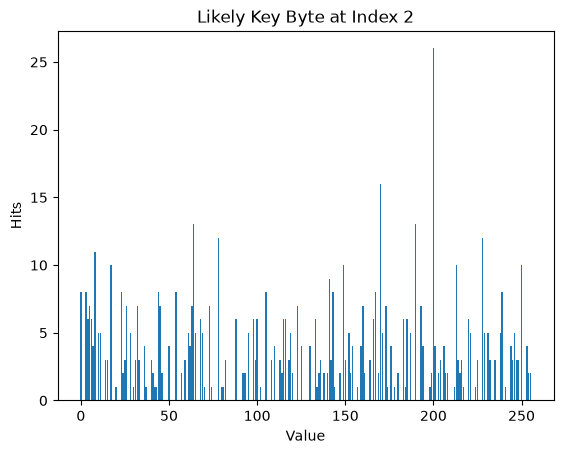

Guessed key: [10, 100, 200]


In [28]:
guessed_key = [None] * 3
for A in range(len(key)):
    frequency = [0] * 256
    for item in data:
        guessed_key[0] = item[0]
        guessed_key[1] = item[1]
        guessed_key[2] = item[2]
        cipher_byte    = item[3]

        # simulate the state array after KSA initialization.
        S = list(range(256))
        j = 0
        for i in range(A + 3):
            j = (j + S[i] + guessed_key[i]) % 256
            S[i], S[j] = S[j], S[i]

        i = A + 3
        z = S[1]
        # if resolved condition is possibly met [Weaknesses in the Key Scheduling Algorithm of RC4, pg 9]
        if z + S[z] == A + 3:
            keystream_byte = cipher_byte ^ 0xAA # SNAP headers all start with 0xAA
            guessed_key_byte = (keystream_byte - j - S[i]) % 256
            frequency[guessed_key_byte] += 1

    plt.xlabel("Value")
    plt.ylabel("Hits")
    plt.title(f"Likely Key Byte at Index {A}")
    plt.bar(range(256), frequency)

    # Display the chart
    plt.show()
    
    # Assume that the most hit is the correct byte.
    most_likely_byte = frequency.index(max(frequency))
    guessed_key.append(most_likely_byte)

print(f"Guessed key: {guessed_key[3:]}")